# Regression Analysis and Predictive Model
## NCRB Crime Data - India (2020-2022)
### Name : Dhanush | Regno : 25MDT0210

## Cell 1 - Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

## Load & Clean Data

In [15]:
df=pd.read_csv('Datasets/NCRB_Table_1A.1.csv')

df.columns=['Sl_No','State','Crimes_2020','Crimes_2021','Crimes_2022',
            'Population_Lakhs','Crime_Rate_2022','Chargesheeting_Rate']

df=df[~df['State'].str.contains('Total',na=False)].reset_index(drop=True)

print('Shape:',df.shape)
df.head()

Shape: (36, 8)


,Sl_No,State,Crimes_2020,Crimes_2021,Crimes_2022,Population_Lakhs,Crime_Rate_2022,Chargesheeting_Rate
0,1,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,2,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,3,Assam,111558,119883,59315,354.9,167.1,32.6
3,4,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,5,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


## Basic Info & Missing Values

In [16]:
print(df.info())
print('\n--- Missing Values ---')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sl_No                36 non-null     object 
 1   State                36 non-null     object 
 2   Crimes_2020          36 non-null     int64  
 3   Crimes_2021          36 non-null     int64  
 4   Crimes_2022          36 non-null     int64  
 5   Population_Lakhs     36 non-null     float64
 6   Crime_Rate_2022      36 non-null     float64
 7   Chargesheeting_Rate  36 non-null     float64
dtypes: float64(3), int64(3), object(2)
memory usage: 2.4+ KB
None

--- Missing Values ---
Sl_No                  0
State                  0
Crimes_2020            0
Crimes_2021            0
Crimes_2022            0
Population_Lakhs       0
Crime_Rate_2022        0
Chargesheeting_Rate    0
dtype: int64


## Summary Statistics

In [17]:
df.describe()

,Crimes_2020,Crimes_2021,Crimes_2022,Population_Lakhs,Crime_Rate_2022,Chargesheeting_Rate
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,118176.555556,101760.000000,98927.194444,383.261111,241.252778,67.991667
std,176923.509449,118652.699382,117142.926576,497.400312,235.523156,20.334367
min,107.000000,89.000000,64.000000,0.700000,45.400000,10.400000
25%,2524.500000,2479.750000,2934.250000,16.075000,138.300000,57.375000
50%,50451.500000,47069.000000,46232.000000,255.250000,175.300000,75.350000
75%,165794.250000,163026.250000,157014.000000,566.250000,292.075000,82.425000
max,891700.000000,367218.000000,401787.000000,2340.900000,1424.100000,96.000000


## Correlation Heatmap

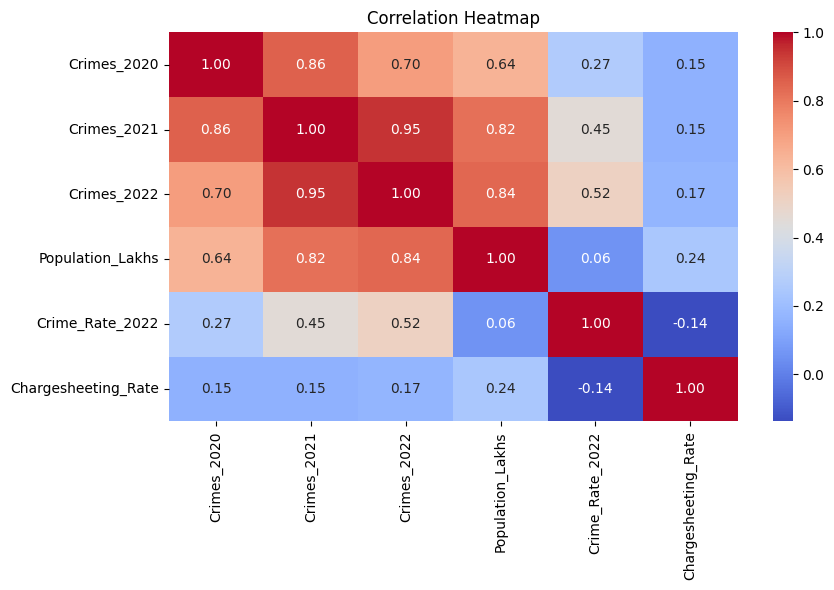

In [18]:
plt.figure(figsize=(9,6))
sns.heatmap(df[['Crimes_2020','Crimes_2021','Crimes_2022',
                'Population_Lakhs','Crime_Rate_2022','Chargesheeting_Rate']].corr(),
            annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Crime Rate by State (Bar Chart)

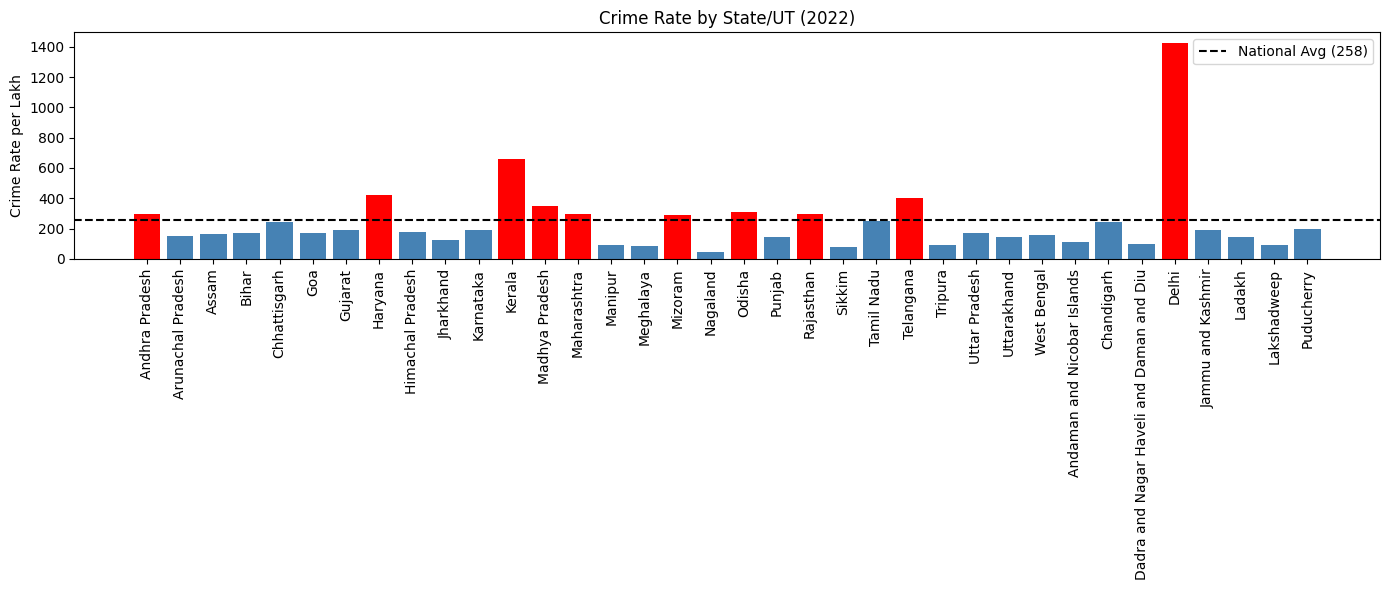

In [19]:
plt.figure(figsize=(14,6))
colors=['red' if x>258 else 'steelblue' for x in df['Crime_Rate_2022']]
plt.bar(df['State'],df['Crime_Rate_2022'],color=colors)
plt.axhline(y=258,color='black',linestyle='--',label='National Avg (258)')
plt.xticks(rotation=90)
plt.title('Crime Rate by State/UT (2022)')
plt.ylabel('Crime Rate per Lakh')
plt.legend()
plt.tight_layout()
plt.show()

## Population vs Crime Rate (Scatter)

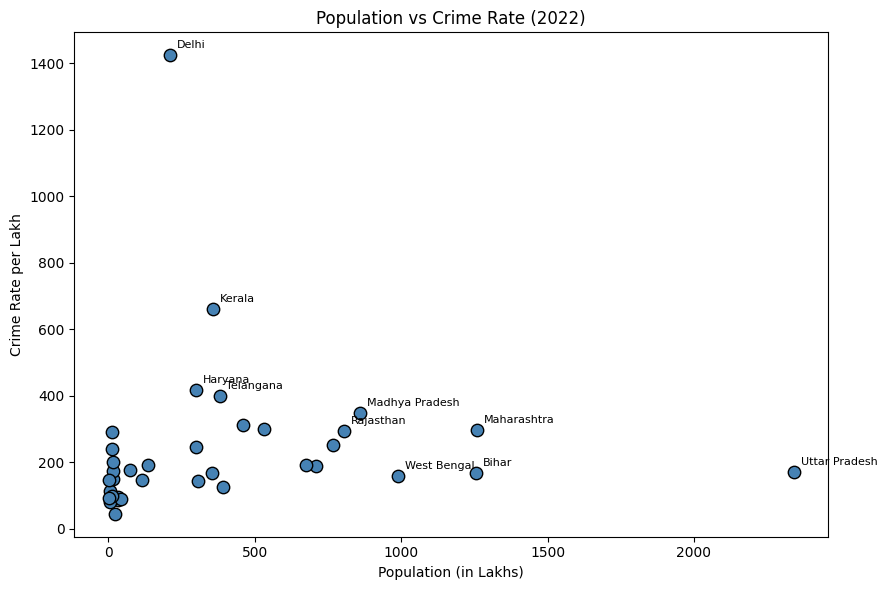

In [20]:
plt.figure(figsize=(9,6))
plt.scatter(df['Population_Lakhs'],df['Crime_Rate_2022'],color='steelblue',edgecolors='black',s=80)
for i,row in df.iterrows():
    if row['Crime_Rate_2022']>400 or row['Population_Lakhs']>800:
        plt.annotate(row['State'],(row['Population_Lakhs'],row['Crime_Rate_2022']),
                     textcoords='offset points',xytext=(5,5),fontsize=8)
plt.title('Population vs Crime Rate (2022)')
plt.xlabel('Population (in Lakhs)')
plt.ylabel('Crime Rate per Lakh')
plt.tight_layout()
plt.show()

## Define X and Y / Train Test Split

In [21]:
x=df[['Crimes_2022','Population_Lakhs','Chargesheeting_Rate']]
y=df['Crime_Rate_2022']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

print('X shape:',x.shape)
print('Y shape:',y.shape)
print('Train size:',len(x_train),'  Test size:',len(x_test))

X shape: (36, 3)
Y shape: (36,)
Train size: 28   Test size: 8


## VIF Check (Multicollinearity)

In [22]:
vif=pd.DataFrame()
vif['Feature']=x.columns
vif['VIF']=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
print(vif)
print('\nAll VIF < 10 - No Multicollinearity Problem')

               Feature       VIF
0          Crimes_2022  5.846151
1     Population_Lakhs  5.647506
2  Chargesheeting_Rate  1.809764

All VIF < 10 - No Multicollinearity Problem


## Multiple Linear Regression

In [23]:
MLR=LinearRegression()
MLR.fit(x_train,y_train)

y_pred=MLR.predict(x_test)
MLR_r2=r2_score(y_test,y_pred)
MLR_rmse=np.sqrt(mean_squared_error(y_test,y_pred))
MLR_mae=mean_absolute_error(y_test,y_pred)

print('R2 Score for Multiple Linear Regression :',round(MLR_r2,4))
print('RMSE for Multiple Linear Regression     :',round(MLR_rmse,4))
print('MAE for Multiple Linear Regression      :',round(MLR_mae,4))

R2 Score for Multiple Linear Regression : 0.5403
RMSE for Multiple Linear Regression     : 279.5613
MAE for Multiple Linear Regression      : 139.954


## OLS Statistical Summary

In [24]:
x_ols=sm.add_constant(df[['Crimes_2022','Population_Lakhs','Chargesheeting_Rate']])
y_ols=df['Crime_Rate_2022']

OLS=sm.OLS(y_ols,x_ols).fit()
print(OLS.summary())

                            OLS Regression Results                            
Dep. Variable:        Crime_Rate_2022   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     35.00
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           3.20e-10
Time:                        11:12:56   Log-Likelihood:                -221.02
No. Observations:                  36   AIC:                             450.0
Df Residuals:                      32   BIC:                             456.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 229.6688    

## MLR Residual Plots

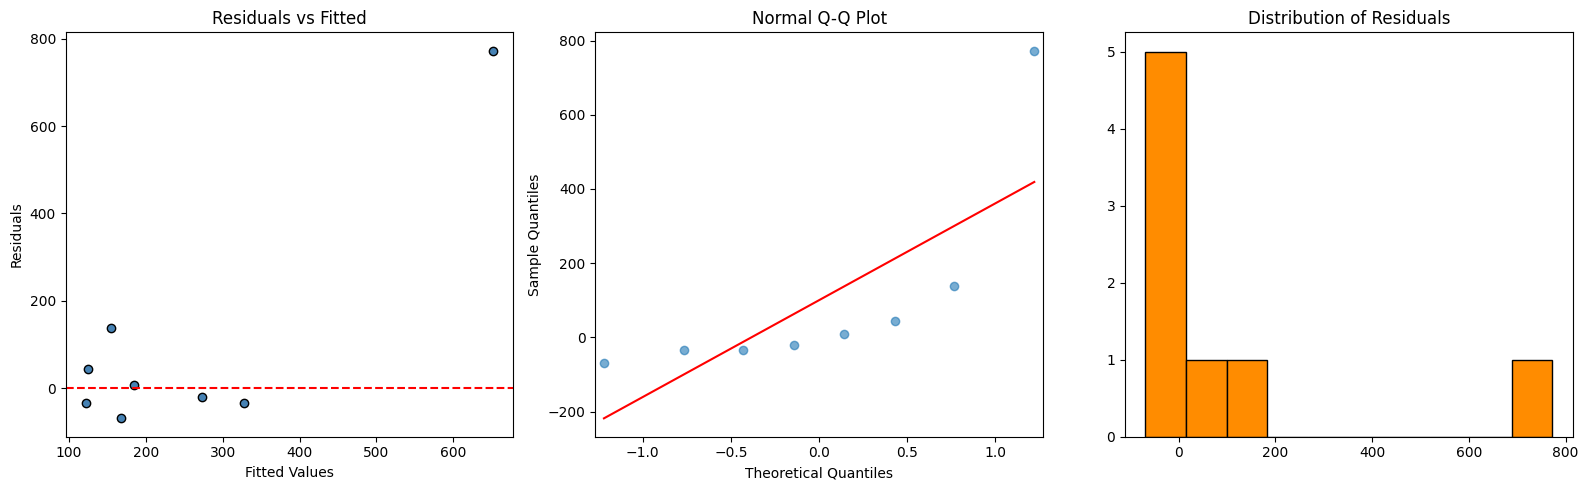

In [25]:
residuals=y_test-y_pred

fig,axes=plt.subplots(1,3,figsize=(16,5))

axes[0].scatter(y_pred,residuals,color='steelblue',edgecolors='black')
axes[0].axhline(0,color='red',linestyle='--')
axes[0].set_title('Residuals vs Fitted')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

sm.qqplot(residuals,line='s',ax=axes[1],alpha=0.6)
axes[1].set_title('Normal Q-Q Plot')

axes[2].hist(residuals,bins=10,color='darkorange',edgecolor='black')
axes[2].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

## Actual vs Predicted (MLR)

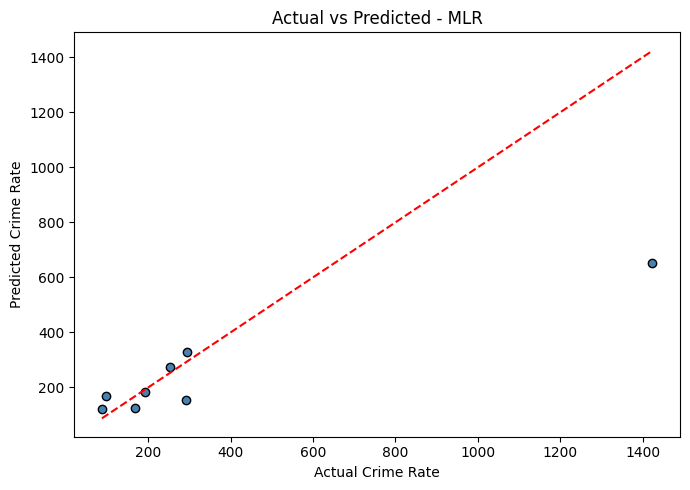

In [26]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred,color='steelblue',edgecolors='black')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.title('Actual vs Predicted - MLR')
plt.xlabel('Actual Crime Rate')
plt.ylabel('Predicted Crime Rate')
plt.tight_layout()
plt.show()

## Create Binary Target for Logistic Regression

In [27]:
df['High_Crime']=df['Crime_Rate_2022'].apply(lambda x: 1 if x>258 else 0)
print(df['High_Crime'].value_counts())

High_Crime
0    26
1    10
Name: count, dtype: int64


## Logistic Regression

In [28]:
x2=df[['Crimes_2022','Population_Lakhs','Chargesheeting_Rate']]
y2=df['High_Crime']

sc=StandardScaler()
x2_scaled=sc.fit_transform(x2)

x2_train,x2_test,y2_train,y2_test=train_test_split(x2_scaled,y2,test_size=0.2,random_state=0)

LR=LogisticRegression()
LR.fit(x2_train,y2_train)

y2_pred=LR.predict(x2_test)
LR_r2=r2_score(y2_test,y2_pred)

print('R2 Score for Logistic Regression :',round(LR_r2,4))
print()
print(classification_report(y2_test,y2_pred))

R2 Score for Logistic Regression : 0.4667

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.85         8
weighted avg       0.90      0.88      0.87         8



## Confusion Matrix

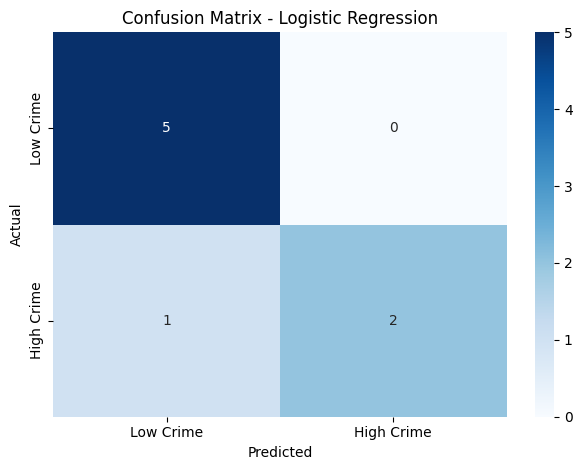

In [29]:
cm=confusion_matrix(y2_test,y2_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Low Crime','High Crime'],
            yticklabels=['Low Crime','High Crime'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## ROC Curve

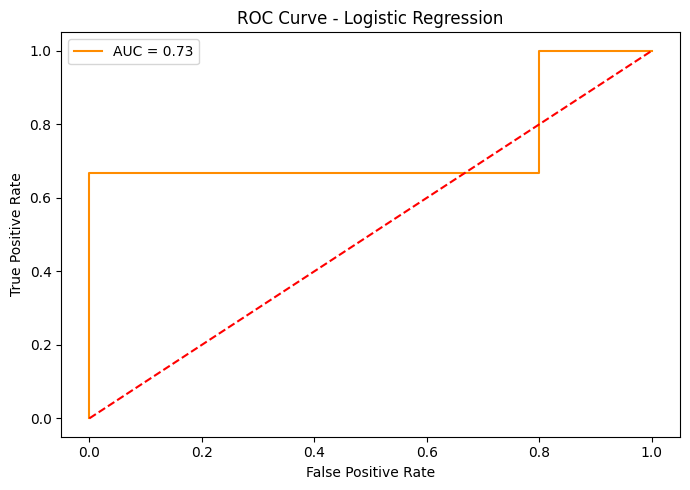

In [30]:
y2_prob=LR.predict_proba(x2_test)[:,1]
fpr,tpr,_=roc_curve(y2_test,y2_prob)
auc=roc_auc_score(y2_test,y2_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,color='darkorange',label='AUC = '+str(round(auc,2)))
plt.plot([0,1],[0,1],'r--')
plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

## Logistic Regression Odds Ratio

In [31]:
x_log=sm.add_constant(df[['Crimes_2022','Population_Lakhs','Chargesheeting_Rate']])
y_log=df['High_Crime']

LOGIT=sm.Logit(y_log,x_log).fit()

odds=pd.DataFrame({
    'Feature':['Intercept','Crimes_2022','Population_Lakhs','Chargesheeting_Rate'],
    'Odds_Ratio':np.exp(LOGIT.params.values)
})
print('Odds Ratio Table :')
print(odds)

         Current function value: 0.000000
         Iterations: 35
Odds Ratio Table :
               Feature  Odds_Ratio
0            Intercept    5.246215
1          Crimes_2022    1.051610
2     Population_Lakhs    0.000003
3  Chargesheeting_Rate    0.789108


C:\Users\DHANUSH\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\DHANUSH\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\DHANUSH\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\discrete\discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
C:\Users\DHANUSH\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Model Comparison Table

In [32]:
results=pd.DataFrame({
    'Model':['Multiple Linear Regression','Logistic Regression'],
    'R2 Score':[round(MLR_r2,4),round(LR_r2,4)],
    'RMSE':[round(MLR_rmse,4),'N/A'],
    'MAE':[round(MLR_mae,4),'N/A'],
    'AUC-ROC':['N/A',round(auc,4)]
})
print(results)

                        Model  R2 Score      RMSE      MAE AUC-ROC
0  Multiple Linear Regression    0.5403  279.5613  139.954     N/A
1         Logistic Regression    0.4667       N/A      N/A  0.7333


## Predict on New Data

In [45]:
new_data=pd.DataFrame({
    'Crimes_2022':[150000],
    'Population_Lakhs':[500],
    'Chargesheeting_Rate':[75]
})

mlr_pred=MLR.predict(new_data)
print('Predicted Crime Rate (MLR)  :',round(mlr_pred[0],2))

new_scaled=sc.transform(new_data)
log_pred=LR.predict(new_scaled)
log_prob=LR.predict_proba(new_scaled)[:,1]
print('Predicted Class (Logistic)  :','High Crime' if log_pred[0]==1 else 'Low Crime')
print('Probability of High Crime   :',round(log_prob[0],4))

Predicted Crime Rate (MLR)  : 284.06
Predicted Class (Logistic)  : Low Crime
Probability of High Crime   : 0.3537


## All India Future Prediction Setup

In [34]:
years=np.array([2020,2021,2022]).reshape(-1,1)
crimes=np.array([4254356,3663360,3561379])

print('Years :',years.flatten())
print('Total Crimes :',crimes)

Years : [2020 2021 2022]
Total Crimes : [4254356 3663360 3561379]


## Fit Trend Model

In [35]:
trend=LinearRegression()
trend.fit(years,crimes)

trend_r2=r2_score(crimes,trend.predict(years))
print('R2 Score for Trend Model    :',round(trend_r2,4))
print('Slope (change per year)     :',round(trend.coef_[0],2))
print('Intercept                   :',round(trend.intercept_,2))

R2 Score for Trend Model    : 0.8576
Slope (change per year)     : -346488.5
Intercept                   : 704079623.5


## Predict All India 2023-2025

In [36]:
future_years=np.array([2023,2024,2025]).reshape(-1,1)
future_crimes=trend.predict(future_years)

pop_2022=13797.5
future_pop=np.array([pop_2022*1.01,pop_2022*1.02,pop_2022*1.03])
future_rate=(future_crimes/future_pop).round(1)

future_df=pd.DataFrame({
    'Year':[2023,2024,2025],
    'Predicted_Crimes':future_crimes.astype(int),
    'Population_Lakhs':future_pop.round(1),
    'Predicted_Crime_Rate':future_rate
})
print('Future Crime Predictions :')
print(future_df)

Future Crime Predictions :
   Year  Predicted_Crimes  Population_Lakhs  Predicted_Crime_Rate
0  2023           3133388           13935.5                 224.8
1  2024           2786899           14073.4                 198.0
2  2025           2440411           14211.4                 171.7


## All India Trend Plot

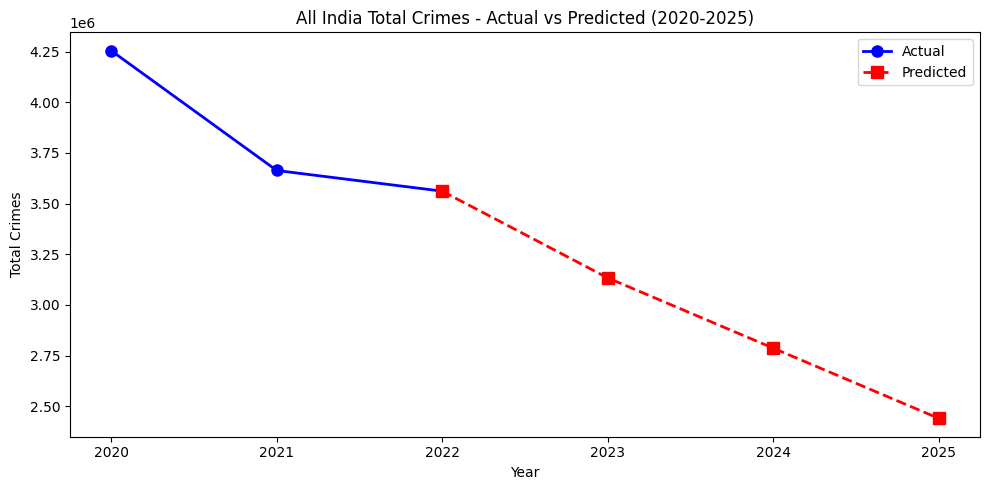

In [37]:
plt.figure(figsize=(10,5))
plt.plot([2020,2021,2022],[4254356,3663360,3561379],
         'bo-',linewidth=2,markersize=8,label='Actual')
plt.plot([2022,2023,2024,2025],
         [3561379]+list(future_crimes.astype(int)),
         'r--s',linewidth=2,markersize=8,label='Predicted')
plt.title('All India Total Crimes - Actual vs Predicted (2020-2025)')
plt.xlabel('Year')
plt.ylabel('Total Crimes')
plt.xticks([2020,2021,2022,2023,2024,2025])
plt.legend()
plt.tight_layout()
plt.show()

## State-wise Crime Rate Prediction (2023-2025)

In [38]:
years=np.array([2020,2021,2022]).reshape(-1,1)
future_years=np.array([2023,2024,2025]).reshape(-1,1)

state_preds=[]

for i,row in df.iterrows():
    crimes=np.array([row['Crimes_2020'],row['Crimes_2021'],row['Crimes_2022']])

    model=LinearRegression()
    model.fit(years,crimes)
    pred_crimes=model.predict(future_years).astype(int)

    pop=row['Population_Lakhs']
    pop_2023=round(pop*1.01,1)
    pop_2024=round(pop*1.02,1)
    pop_2025=round(pop*1.03,1)

    rate_2023=round(pred_crimes[0]/pop_2023,1)
    rate_2024=round(pred_crimes[1]/pop_2024,1)
    rate_2025=round(pred_crimes[2]/pop_2025,1)

    state_preds.append({
        'State':row['State'],
        'Actual_Rate_2022':row['Crime_Rate_2022'],
        'Predicted_Rate_2023':rate_2023,
        'Predicted_Rate_2024':rate_2024,
        'Predicted_Rate_2025':rate_2025
    })

pred_df=pd.DataFrame(state_preds)
print(pred_df.head(10))

               State  Actual_Rate_2022  Predicted_Rate_2023  \
0     Andhra Pradesh             299.0                271.2   
1  Arunachal Pradesh             148.8                156.4   
2              Assam             167.1                124.7   
3              Bihar             168.1                168.5   
4       Chhattisgarh             246.5                259.4   
5                Goa             172.8                129.1   
6            Gujarat             189.8                 22.2   
7            Haryana             418.6                449.2   
8   Himachal Pradesh             177.8                161.4   
9          Jharkhand             124.5                118.5   

   Predicted_Rate_2024  Predicted_Rate_2025  
0                240.4                210.2  
1                157.5                157.5  
2                 51.3                -20.7  
3                173.3                177.9  
4                270.9                282.2  
5                106.9        

## Top 10 High Crime States in 2025

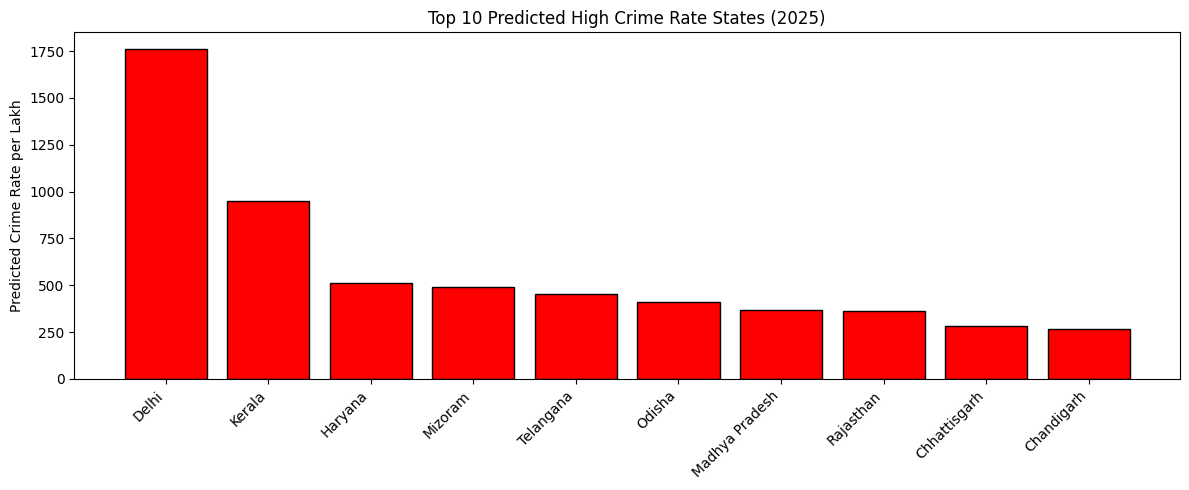

In [39]:
top10=pred_df.nlargest(10,'Predicted_Rate_2025')[['State','Predicted_Rate_2025']]

plt.figure(figsize=(12,5))
plt.bar(top10['State'],top10['Predicted_Rate_2025'],color='red',edgecolor='black')
plt.xticks(rotation=45,ha='right')
plt.title('Top 10 Predicted High Crime Rate States (2025)')
plt.ylabel('Predicted Crime Rate per Lakh')
plt.tight_layout()
plt.show()

## Plot Any Specific State Trend

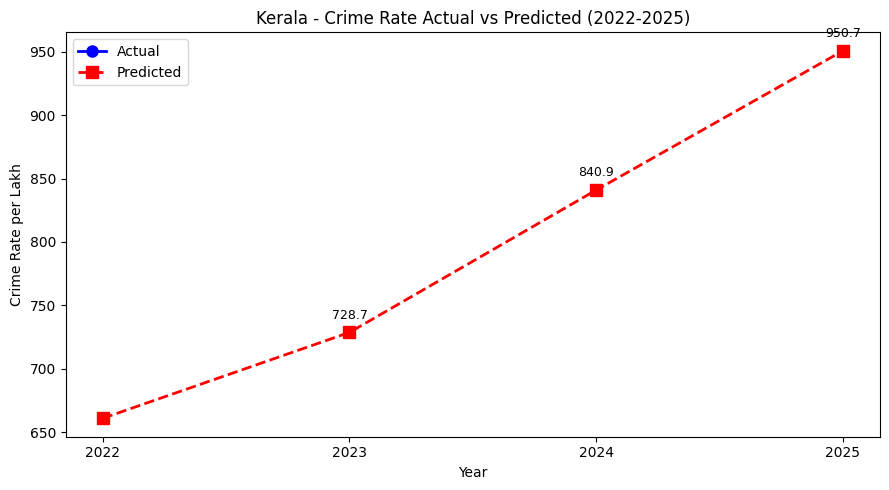

In [40]:
state_name='Kerala'

row=pred_df[pred_df['State']==state_name].iloc[0]
actual_rate=df[df['State']==state_name]['Crime_Rate_2022'].values[0]

pred_y=[row['Predicted_Rate_2023'],row['Predicted_Rate_2024'],row['Predicted_Rate_2025']]

plt.figure(figsize=(9,5))
plt.plot([2022],[actual_rate],'bo-',linewidth=2,markersize=8,label='Actual')
plt.plot([2022,2023,2024,2025],[actual_rate]+pred_y,'r--s',linewidth=2,markersize=8,label='Predicted')

for i,val in zip([2023,2024,2025],pred_y):
    plt.annotate(str(val),(i,val),textcoords='offset points',xytext=(0,10),ha='center',fontsize=9)

plt.title(state_name+' - Crime Rate Actual vs Predicted (2022-2025)')
plt.xlabel('Year')
plt.ylabel('Crime Rate per Lakh')
plt.xticks([2022,2023,2024,2025])
plt.legend()
plt.tight_layout()
plt.show()

## State-wise Heatmap (2022-2025)

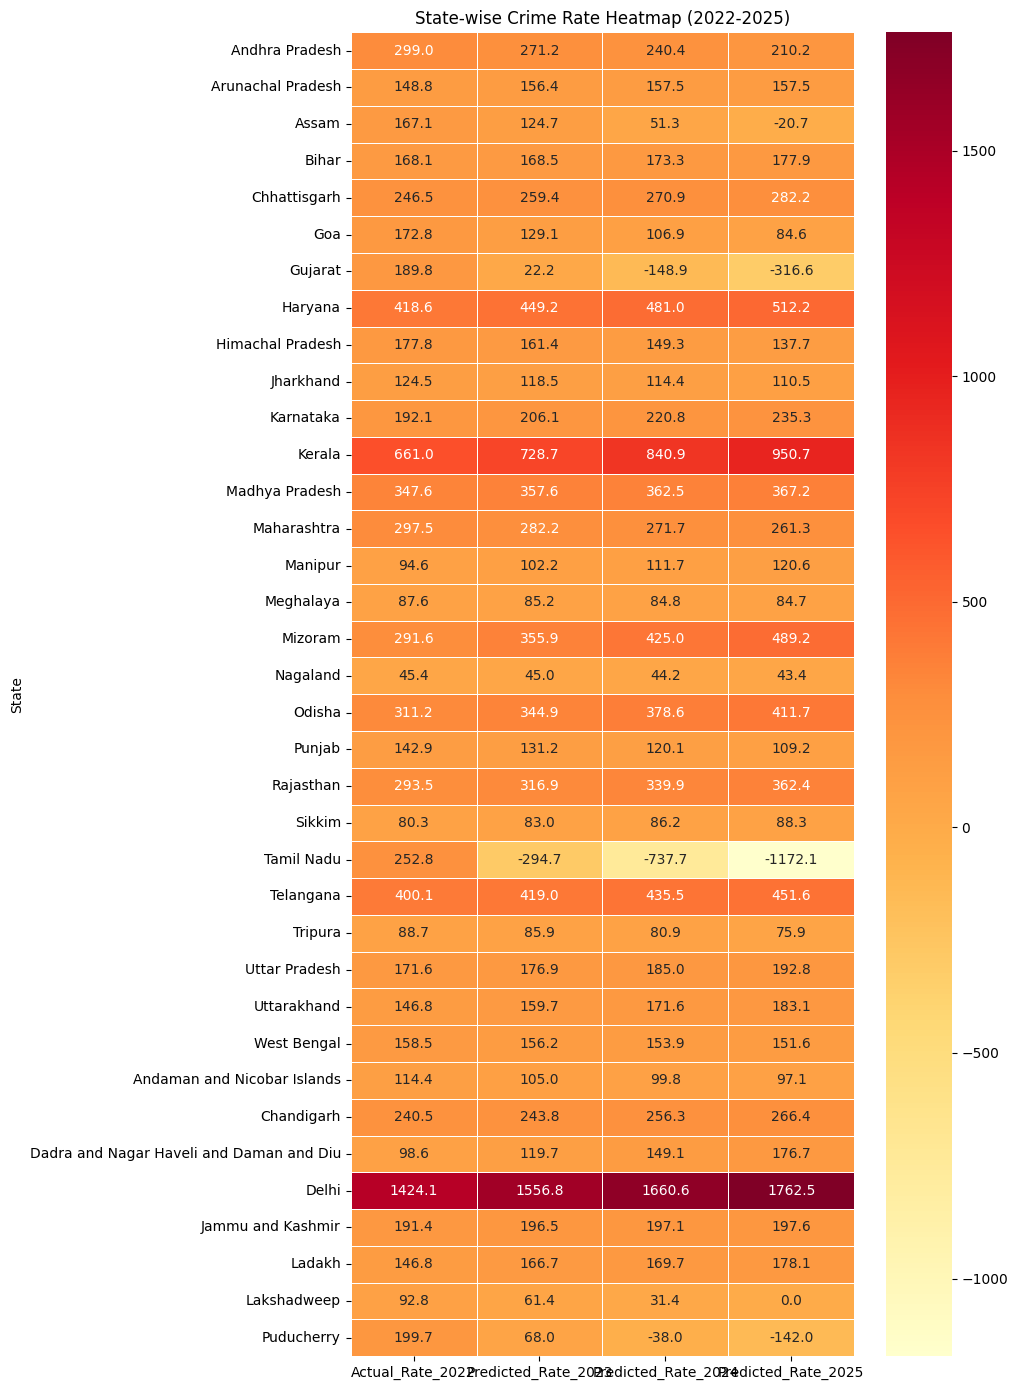

In [41]:
heat_df=pred_df.set_index('State')[['Actual_Rate_2022','Predicted_Rate_2023',
                                     'Predicted_Rate_2024','Predicted_Rate_2025']]

plt.figure(figsize=(10,14))
sns.heatmap(heat_df,annot=True,fmt='.1f',cmap='YlOrRd',linewidths=0.5)
plt.title('State-wise Crime Rate Heatmap (2022-2025)')
plt.tight_layout()
plt.show()

## Save Predictions to CSV

In [42]:
pred_df.to_csv('State_Crime_Rate_Predictions_2023_2025.csv',index=False)
print('Predictions saved successfully!')

Predictions saved successfully!
